In [1]:
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"

target_lat=30

In [2]:
target_var = "ta"
# output_file = "/gws/ssde/j25b/impose/bidyut/analysis_transient_data/VCorr_Temperature_G6sulfur_and_SSP245_2021-2050.nc"
output_file = "/gws/ssde/j25b/impose/bidyut/analysis_transient_data/VCorr_Temperature_G6sulfur_and_SSP245.nc" #2071-2100 is without year tags

In [3]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [4]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2050-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/home/users/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=30))

def roll_and_regrid_3d(ds, target_lat=30):
    """Roll and regrid, handling both 2D and 3D data."""
    ds = roll_lon(ds)
    
    if 'plev' in ds.dims or 'lev' in ds.dims:
        lev_dim = 'plev' if 'plev' in ds.dims else 'lev'
        regridded_levels = []
        for lev_val in ds[lev_dim].values:
            level_data = ds.sel({lev_dim: lev_val})
            regridded = regrid_to_common(level_data, target_lat=target_lat)
            regridded_levels.append(regridded)
        return xr.concat(regridded_levels, dim=lev_dim)
    else:
        return regrid_to_common(ds, target_lat=target_lat)

In [5]:
# def vertical_levelwise_correlation(ds_ta):
#     """
#     Compute vertical level-wise correlation for temperature anomalies.
    
#     For each grid point and each month, computes Pearson correlation between
#     temperature anomalies at each pair of vertical levels.
    
#     Following Lin & Emanuel (2024) PNAS: correlates temperature anomalies
#     at vertical level i with anomalies at vertical level j, per degree of
#     warming at level j.
    
#     Parameters
#     ----------
#     ds_ta : xr.Dataset
#         Dataset containing 'ta' (air temperature) with dimensions 
#         (time, plev, lat, lon)
    
#     Returns
#     -------
#     xr.Dataset
#         Dataset containing:
#         - vcorr: vertical correlation matrix (month, plev_i, plev_j, lat, lon)
#         where plev_i is the ordinate (response level) and plev_j is the 
#         abscissa (predictor level)
#     """
#     import xarray as xr
#     import numpy as np
#     from scipy.stats import pearsonr
    
#     ta = ds_ta['ta']
    
#     # Group by month to get monthly climatology
#     ta_monthly_clim = ta.groupby('time.month').mean('time')
    
#     # Calculate anomalies by removing monthly climatology
#     ta_anom = ta.groupby('time.month') - ta_monthly_clim
    
#     # Get dimensions
#     nmonths = 12
#     nlevels = len(ta.plev)
#     nlat = len(ta.lat)
#     nlon = len(ta.lon)
    
#     # Initialize output array: (month, plev_i, plev_j, lat, lon)
#     vcorr = np.full((nmonths, nlevels, nlevels, nlat, nlon), np.nan)
    
#     # Loop over each month
#     for imonth in range(1, 13):
#         print(f"    Processing month {imonth}/12")
        
#         # Select data for this month
#         ta_month = ta_anom.sel(time=ta_anom.time.dt.month == imonth)
        
#         # Loop over each grid point
#         for ilat in range(nlat):
#             for ilon in range(nlon):
#                 # Extract time series at this grid point for all levels
#                 # Shape: (ntime, nlevels)
#                 ts = ta_month.isel(lat=ilat, lon=ilon).values
                
#                 # Skip if all NaN at this location
#                 if np.all(np.isnan(ts)):
#                     continue
                
#                 # Compute correlation between each pair of levels
#                 for i in range(nlevels):  # ordinate (response)
#                     for j in range(nlevels):  # abscissa (predictor)
#                         x = ts[:, j]  # predictor level
#                         y = ts[:, i]  # response level
                        
#                         # Remove NaN pairs
#                         mask = ~(np.isnan(x) | np.isnan(y))
#                         if np.sum(mask) < 3:  # need at least 3 points
#                             continue
                        
#                         x_clean = x[mask]
#                         y_clean = y[mask]
                        
#                         # Skip if no variance
#                         if np.std(x_clean) == 0 or np.std(y_clean) == 0:
#                             continue
                        
#                         # Compute Pearson correlation
#                         corr, _ = pearsonr(x_clean, y_clean)
#                         vcorr[imonth-1, i, j, ilat, ilon] = corr
    
#     # Create output dataset
#     ds_out = xr.Dataset(
#         {
#             'vcorr': (['month', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)
#         },
#         coords={
#             'month': np.arange(1, 13),
#             'plev_i': ta.plev.values,  # ordinate (response level)
#             'plev_j': ta.plev.values,  # abscissa (predictor level)
#             'lat': ta.lat.values,
#             'lon': ta.lon.values
#         },
#         attrs={
#             'description': 'Vertical level-wise correlation of temperature anomalies',
#             'method': 'Pearson correlation between T anomalies at level i vs level j',
#             'reference': 'Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.2319228121',
#             'anomaly_base': 'Monthly climatology removed'
#         }
#     )
    
#     return ds_out

In [6]:
# def vertical_levelwise_correlation(ds_ta):
#     """
#     Compute vertical level-wise correlation for temperature anomalies (vectorized).
#     """
#     import xarray as xr
#     import numpy as np
    
#     ta = ds_ta['ta']
    
#     # Group by month to get monthly climatology
#     ta_monthly_clim = ta.groupby('time.month').mean('time')
    
#     # Calculate anomalies by removing monthly climatology
#     ta_anom = ta.groupby('time.month') - ta_monthly_clim
    
#     # Get dimensions
#     nmonths = 12
#     nlevels = len(ta.plev)
#     nlat = len(ta.lat)
#     nlon = len(ta.lon)
    
#     print(f"    Array dimensions: nlevels={nlevels}, nlat={nlat}, nlon={nlon}")
    
#     # Initialize output array: (month, plev_i, plev_j, lat, lon)
#     vcorr = np.full((nmonths, nlevels, nlevels, nlat, nlon), np.nan)
    
#     # Loop over each month
#     for imonth in range(1, 13):
#         print(f"    Processing month {imonth}/12", end='')
        
#         # Select data for this month: (ntime, plev, lat, lon)
#         ta_month = ta_anom.sel(time=ta_anom.time.dt.month == imonth)
        
#         if len(ta_month.time) < 2:
#             print(f" - skipping (only {len(ta_month.time)} time steps)")
#             continue
            
#         data = ta_month.values  # (ntime, plev, lat, lon)
#         ntime = data.shape[0]
        
#         print(f" ({ntime} time steps)")
        
#         # Reshape to (ntime, plev, nlat*nlon)
#         data_reshaped = data.reshape(ntime, nlevels, nlat * nlon)
        
#         # Loop over each pair of levels
#         for i in range(nlevels):  # ordinate (response)
#             for j in range(nlevels):  # abscissa (predictor)
#                 # Extract all spatial points for these two levels
#                 x = data_reshaped[:, j, :]  # (ntime, nlat*nlon)
#                 y = data_reshaped[:, i, :]  # (ntime, nlat*nlon)
                
#                 # Compute correlation coefficient for all grid points at once
#                 # Using numpy correlation formula: corr = cov(x,y) / (std(x) * std(y))
                
#                 # Remove time mean for each grid point
#                 x_mean = np.nanmean(x, axis=0, keepdims=True)
#                 y_mean = np.nanmean(y, axis=0, keepdims=True)
#                 x_anom = x - x_mean
#                 y_anom = y - y_mean
                
#                 # Compute covariance and standard deviations
#                 cov = np.nanmean(x_anom * y_anom, axis=0)
#                 std_x = np.nanstd(x, axis=0)
#                 std_y = np.nanstd(y, axis=0)
                
#                 # Compute correlation
#                 with np.errstate(divide='ignore', invalid='ignore'):
#                     corr = cov / (std_x * std_y)
                
#                 # Reshape back to (nlat, nlon) and store
#                 vcorr[imonth-1, i, j, :, :] = corr.reshape(nlat, nlon)
    
#     # Create output dataset
#     ds_out = xr.Dataset(
#         {
#             'vcorr': (['month', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)
#         },
#         coords={
#             'month': np.arange(1, 13),
#             'plev_i': ta.plev.values,
#             'plev_j': ta.plev.values,
#             'lat': ta.lat.values,
#             'lon': ta.lon.values
#         },
#         attrs={
#             'description': 'Vertical level-wise correlation of temperature anomalies',
#             'method': 'Pearson correlation between T anomalies at level i vs level j',
#             'reference': 'Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.2319228121',
#             'anomaly_base': 'Monthly climatology removed',
#             'note': 'Months with <2 time steps are skipped (NaN)'
#         }
#     )
    
#     return ds_out

In [7]:
def vertical_levelwise_correlation(ds_ta):
    """
    Compute vertical level-wise correlation for temperature anomalies (vectorized).
    """
    import xarray as xr
    import numpy as np
    
    ta = ds_ta['ta']
    
    # Group by month to get monthly climatology
    ta_monthly_clim = ta.groupby('time.month').mean('time')
    
    # Calculate anomalies by removing monthly climatology
    ta_anom = ta.groupby('time.month') - ta_monthly_clim
    
    # Get dimensions
    nmonths = 12
    nlevels = len(ta.plev)
    nlat = len(ta.lat)
    nlon = len(ta.lon)
    
    print(f"    Array dimensions: nlevels={nlevels}, nlat={nlat}, nlon={nlon}")
    print(f"    Original data shape: {ta.shape}")
    print(f"    Dimension order: {ta.dims}")
    
    # Initialize output array: (month, plev_i, plev_j, lat, lon)
    vcorr = np.full((nmonths, nlevels, nlevels, nlat, nlon), np.nan)
    
    # Loop over each month
    for imonth in range(1, 13):
        print(f"    Processing month {imonth}/12", end='')
        
        # Select data for this month
        ta_month = ta_anom.sel(time=ta_anom.time.dt.month == imonth)
        
        if len(ta_month.time) < 2:
            print(f" - skipping (only {len(ta_month.time)} time steps)")
            continue
        
        ntime = len(ta_month.time)
        print(f" ({ntime} time steps)")
        
        # Ensure correct dimension order: (time, plev, lat, lon)
        ta_month = ta_month.transpose('time', 'plev', 'lat', 'lon')
        data = ta_month.values
        
        print(f"      Data shape after transpose: {data.shape}")
        
        # Reshape to (ntime, plev, nlat*nlon)
        data_reshaped = data.reshape(ntime, nlevels, nlat * nlon)
        
        # Loop over each pair of levels
        for i in range(nlevels):  # ordinate (response)
            for j in range(nlevels):  # abscissa (predictor)
                # Extract all spatial points for these two levels
                x = data_reshaped[:, j, :]  # (ntime, nlat*nlon)
                y = data_reshaped[:, i, :]  # (ntime, nlat*nlon)
                
                # Compute correlation coefficient for all grid points at once
                # Using numpy correlation formula: corr = cov(x,y) / (std(x) * std(y))
                
                # Remove time mean for each grid point
                x_mean = np.nanmean(x, axis=0, keepdims=True)
                y_mean = np.nanmean(y, axis=0, keepdims=True)
                x_anom = x - x_mean
                y_anom = y - y_mean
                
                # Compute covariance and standard deviations
                cov = np.nanmean(x_anom * y_anom, axis=0)
                std_x = np.nanstd(x, axis=0)
                std_y = np.nanstd(y, axis=0)
                
                # Compute correlation
                with np.errstate(divide='ignore', invalid='ignore'):
                    corr = cov / (std_x * std_y)
                
                # Reshape back to (nlat, nlon) and store
                vcorr[imonth-1, i, j, :, :] = corr.reshape(nlat, nlon)
    
    # Create output dataset
    ds_out = xr.Dataset(
        {
            'vcorr': (['month', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)
        },
        coords={
            'month': np.arange(1, 13),
            'plev_i': ta.plev.values,
            'plev_j': ta.plev.values,
            'lat': ta.lat.values,
            'lon': ta.lon.values
        },
        attrs={
            'description': 'Vertical level-wise correlation of temperature anomalies',
            'method': 'Pearson correlation between T anomalies at level i vs level j',
            'reference': 'Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.2319228121',
            'anomaly_base': 'Monthly climatology removed',
            'note': 'Months with <2 time steps are skipped (NaN)'
        }
    )
    
    return ds_out

In [8]:
def VPATCORR_pattern_vertical(ds_ta):
    """
    Pattern correlation of temperature anomalies across vertical levels.
    
    For each month and reference level j:
    - Computes the Pearson correlation between the
      spatio-temporal anomaly pattern at level j
      and that at all other levels.
    
    Pattern defined over:
    - 30S–30N latitude band
    - all longitudes (treated as tiles)
    - all available times in the month
    
    Output dimensions:
    (model, experiment, month, plev_i, plev_j)
    """

    import numpy as np
    import xarray as xr

    ta = ds_ta['ta']

    # ---------
    # 1. Monthly anomalies
    # ---------
    # ta_clim = ta.groupby('time.month').mean('time')
    # ta_anom = ta.groupby('time.month') - ta_clim
    # Calculate anomalies by removing zonal mean
    ta_zonal_mean = ta.mean(dim='lon')
    ta_anom = ta - ta_zonal_mean

    
    # ---------
    # 2. Latitude selection (30S–30N)
    # ---------
    ta_anom = ta_anom.sel(lat=slice(-30, 30))

    # Dimensions
    nmonths = 12
    nlev = ta.plev.size

    # Initialize output
    pcorr = np.full((nmonths, nlev, nlev), np.nan)

    # ---------
    # 3. Loop over months
    # ---------
    for imonth in range(1, 13):

        ta_m = ta_anom.sel(time=ta_anom.time.dt.month == imonth)

        if ta_m.time.size < 2:
            continue

        # Enforce dimension order
        # (time, plev, lat, lon)
        ta_m = ta_m.transpose('time', 'plev', 'lat', 'lon')

        # Collapse lat by averaging (pattern lives in lon × time)
        ta_m = ta_m.mean(dim='lat')

        # Reshape to (plev, time*lon)
        data = ta_m.values
        ntime, nlev, nlon = data.shape
        data_flat = data.reshape(ntime * nlon, nlev).T  # (plev, space)

        # ---------
        # 4. Pattern correlation in vertical space
        # ---------
        for j in range(nlev):          # reference level
            ref = data_flat[j]

            # Remove mean
            ref = ref - np.nanmean(ref)

            for i in range(nlev):      # target level
                tgt = data_flat[i]
                tgt = tgt - np.nanmean(tgt)

                num = np.nanmean(ref * tgt)
                den = np.nanstd(ref) * np.nanstd(tgt)

                if den > 0:
                    pcorr[imonth-1, i, j] = num / den

    # ---------
    # 5. Output dataset
    # ---------
    ds_out = xr.Dataset(
        data_vars=dict(
            vpatcorr=(['month', 'plev_i', 'plev_j'], pcorr)
        ),
        coords=dict(
            month=np.arange(1, 13),
            plev_i=ta.plev.values,
            plev_j=ta.plev.values
        ),
        attrs=dict(
            description='Vertical pattern correlation of temperature anomalies',
            method='Pearson correlation of spatio-temporal anomaly patterns',
            lat_band='30S–30N',
            anomaly_base='Monthly climatology removed'
        )
    )

    return ds_out

In [9]:
"""
CORRELATION SECTION
"""


import os

if not os.path.exists(output_file):
    print('#'*40)
    print("File does not exist — running code")
    print('#'*40)


    # ================================================================
    # MAIN PROCESSING LOOP
    # ================================================================
    
    all_results = {}
    
    for model_name, model_meta in MODELS.items():
    
        vcorr_by_exp = {}  # Store all components for each experiment
        seasonal_data = {}      # Store seasonal means by year
    
        # ----------------------------
        # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
        # ----------------------------
        for exp, meta in EXPERIMENTS.items():
    
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
    
            def make_base(vname):
                return (
                    CEDA_BASE
                    / meta["project"]
                    / model_meta["institution"]
                    / model_name
                    / meta["scenario"]
                    / ensemble
                    / "Amon"
                    / vname
                    / model_meta["grid"]
                    / "latest"
                )
    

            # target_var = "wap"
            base_ta = make_base("ta")

            
            ####### Handle ALTERNATE base paths ######
            ds_ta = load_model_data_alt_path(base_ta, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, "ta")


            #Slicing data
            t_start, t_end = _time_slice(exp)
            ds_sliced = ds_ta.sel(time=slice(t_start, t_end))
            
            # Roll and regrid
            ds_ta = roll_and_regrid_3d(ds_sliced, target_lat=30)
            
            print(f"  [{model_name}] {exp}: ta loaded {ds_ta.sizes['time']} months "
                  f"({ds_ta.time.values[0]} → {ds_ta.time.values[-1]})")

            
            # Calculate vertical correlation
            print(f"  [{model_name}] {exp}: Calculating vertical correlation")
            vcorr = vertical_levelwise_correlation(ds_ta)
            # vcorr = VPATCORR_pattern_vertical(ds_ta)
            
            # Store for this experiment
            vcorr_by_exp[exp] = vcorr
    
        # After all experiments for this model
        all_results[model_name] = vcorr_by_exp
    
    
    # ================================================================
    # 5) CREATE OUTPUT NETCDF FILE
    # ================================================================
    
    # Stack all models into one dataset
    model_list = []
    for model_name in all_results.keys():
        exp_list = []
        for exp in EXPERIMENTS.keys():
            if exp in all_results[model_name]:
                ds = all_results[model_name][exp]
                ds = ds.expand_dims({'experiment': [exp]})
                exp_list.append(ds)
        
        # Combine experiments for this model
        if exp_list:
            ds_model = xr.concat(exp_list, dim='experiment')
            ds_model = ds_model.expand_dims({'model': [model_name]})
            model_list.append(ds_model)
    
    # Combine all models
    ds_combined = xr.concat(model_list, dim='model')
    
    # Save
    print(f"\nSaving to {output_file}...")
    ds_combined.to_netcdf(output_file)
    print(f"✓ Saved successfully!")
    print(f"  Dimensions: {dict(ds_combined.dims)}")
    print(f"  Variables: {list(ds_combined.data_vars)}")

else:
    print('#'*40)
    print(f"{output_file} already exists — skipping its computation")
    print('#'*40)

########################################
/gws/ssde/j25b/impose/bidyut/analysis_transient_data/VCorr_Temperature_G6sulfur_and_SSP245.nc already exists — skipping its computation
########################################


# Plotting

In [10]:
# Load the dataset
ds_corr = xr.open_dataset(output_file)

In [11]:
print('ds_corr', ds_corr)

ds_corr <xarray.Dataset> Size: 1GB
Dimensions:     (model: 5, experiment: 2, month: 12, plev_i: 19, plev_j: 19,
                 lat: 25, lon: 144)
Coordinates:
  * model       (model) <U13 260B 'UKESM1-0-LL' 'CNRM-ESM2-1' ... 'IPSL-CM6A-LR'
  * experiment  (experiment) <U8 64B 'G6sulfur' 'SSP245'
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev_i      (plev_i) float64 152B 1e+05 9.25e+04 8.5e+04 ... 500.0 100.0
  * plev_j      (plev_j) float64 152B 1e+05 9.25e+04 8.5e+04 ... 500.0 100.0
  * lat         (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 25.0 27.5 30.0
  * lon         (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Data variables:
    vcorr       (model, experiment, month, plev_i, plev_j, lat, lon) float64 1GB ...
Attributes:
    description:   Vertical level-wise correlation of temperature anomalies
    method:        Pearson correlation between T anomalies at level i vs level j
    reference:     Following Lin & Emanuel (2024) PNAS doi:1

In [12]:
# import matplotlib.pyplot as plt
# import numpy as np

# # select data
# da = ds_corr.vpatcorr.sel(
#     model='CESM2-WACCM',
#     experiment='SSP245',
#     month=[1,2,3,4,5,6,7,8,9,10,11,12]
# ).mean('month')

# plev = da.plev_i.values

# fig, ax = plt.subplots(figsize=(6, 5))

# cf = ax.contourf(
#     plev, plev, da.values,
#     levels=np.linspace(-1, 1, 81),
#     cmap='RdBu_r',
#     extend='both'
# )

# # ax.contour(
# #     plev, plev, da.values,
# #     levels=np.arange(-0.8, 1.0, 0.05),
# #     colors='k',
# #     linewidths=0.6
# # )

# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.invert_xaxis()
# ax.invert_yaxis()

# ax.set_xlabel('Reference level (Pa)')
# ax.set_ylabel('Target level (Pa)')
# ax.set_title('Vertical pattern correlation (Annual, 30°S–30°N)')

# cbar = fig.colorbar(cf, ax=ax)
# cbar.set_label('Pattern correlation')

# plt.tight_layout()
# plt.show()

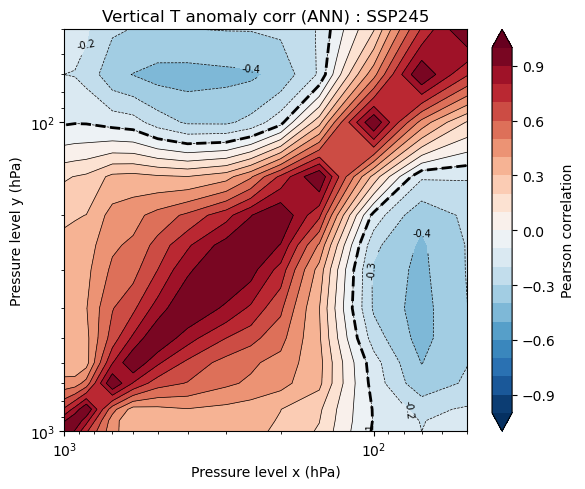

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selection ---
ds = ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='SSP245',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

# --- DJF mean ---
# ds_djf = ds.sel(month=[12, 1, 2]).vcorr.mean(dim=['month', 'lat', 'lon'])
ds_djf = ds.vcorr.mean(dim=['month', 'lat', 'lon']) # this is annual mean


# Pressure levels
plev = ds_djf.plev_i.values/100

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    plev, plev, ds_djf.values,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)

cs = ax.contour(
    plev, plev, ds_djf.values,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)
# ax.clabel(cs, cs.levels[0.6], inline=True, fontsize=7, fmt='%.1f')
# label only levels <= -0.6
ax.clabel(cs, levels=cs.levels[cs.levels <= -0.1], inline=True, fontsize=7, fmt='%.1f')

ax.contour(
    plev, plev, ds_djf.values,
    levels=[-0.1],
    colors='k',
    linewidths=2
)

# Log-pressure axis like meteorology
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000,50)
ax.set_xlim(1000,50)

ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : SSP245')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')

plt.tight_layout()
plt.show()

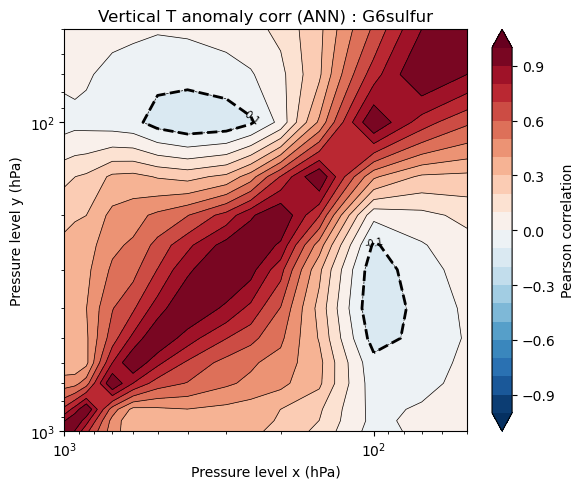

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selection ---
ds = ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='G6sulfur',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

# --- DJF mean ---
# ds_djf = ds.sel(month=[12, 1, 2]).vcorr.mean(dim=['month', 'lat', 'lon'])
ds_djf = ds.vcorr.mean(dim=['month', 'lat', 'lon']) # this is annual mean

# Pressure levels
plev = ds_djf.plev_i.values/100

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    plev, plev, ds_djf.values,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)

cs = ax.contour(
    plev, plev, ds_djf.values,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)
# ax.clabel(cs, cs.levels[0.6], inline=True, fontsize=7, fmt='%.1f')
# label only levels <= -0.6
ax.clabel(cs, levels=cs.levels[cs.levels <= -0.1], inline=True, fontsize=7, fmt='%.1f')

ax.contour(
    plev, plev, ds_djf.values,
    levels=[-0.1],
    colors='k',
    linewidths=2
)

# Log-pressure axis like meteorology
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000,50)
ax.set_xlim(1000,50)

ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : G6sulfur')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')

plt.tight_layout()
plt.show()